# 09. MambaGaze — Mamba SSM 기반 AutoGaze 아키텍처 프로토타입

> **v1**: AR Mamba decoder (SSM으로 LLaMA 대체, 여전히 순차 생성)  
> **v2 (신규)**: Feedforward Non-AR (단일 pass, 병렬 중요도 예측, Branch A)

## 목차
1. 폰트 검증 (Font Validation)
2. 세 가지 아키텍처 비교
3. Selective SSM (S6) 알고리즘 시각화
4. Spatial Zigzag Scan 패턴
5. v1 AR 모델 파라미터 수 비교
6. **v2 FF 모델 인스턴스화 & 파라미터 수**
7. **v2 FF Forward Pass 데모**
8. **v2 Importance Score 히트맵 시각화**
9. SSM 상태 크기 vs KV 캐시 비교
10. SelectiveSSM 내부 Δ 시각화
11. Gaze Map 비교: v1 AR vs v2 FF
12. 요약 및 다음 단계

In [1]:
import sys
sys.path.insert(0, "..")

import os, warnings
import torch
import torch.nn.functional as F
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
warnings.filterwarnings("ignore")

def _configure_mpl_cjk():
    matplotlib.rcParams["axes.unicode_minus"] = False
    try:
        import matplotlib.font_manager as fm
        for name in ["Apple SD Gothic Neo", "AppleGothic", "NanumGothic",
                     "Noto Sans CJK KR", "Noto Sans CJK JP", "DejaVu Sans"]:
            try:
                path = fm.findfont(fm.FontProperties(family=name), fallback_to_default=False)
                if path and os.path.exists(path):
                    matplotlib.rcParams["font.family"] = name
                    return name
            except Exception:
                pass
    except Exception:
        pass
    return "default"

font_name = _configure_mpl_cjk()

# MambaGaze v1 (AR)
from autogaze.models.mamba_gaze import (
    MambaGaze, MambaGazeConfig,
    MambaVisionEncoder, MambaGazeDecoder,
    MambaBlock, SelectiveSSM,
)
from autogaze.models.mamba_gaze.configuration_mamba_gaze import (
    MambaVisionConfig, MambaDecoderConfig, MambaGazeModelConfig,
)

# MambaGaze v2 (Feedforward)
from autogaze.models.mamba_gaze import (
    MambaGazeFF, MambaGazeFFConfig,
    LightweightCNNEncoder, SaliencyHead, SpatioTemporalMambaAggregator,
)

device = "mps" if torch.backends.mps.is_available() else "cpu"
print(f"device: {device}")
print(f"matplotlib font: {font_name}")

device: mps
matplotlib font: Apple SD Gothic Neo


---
## 1. 폰트 검증 (Font Validation)

PIL과 matplotlib 양쪽에서 한국어 텍스트가 올바르게 렌더링되는지 확인한다.

PIL 폰트 경로: /System/Library/Fonts/AppleSDGothicNeo.ttc


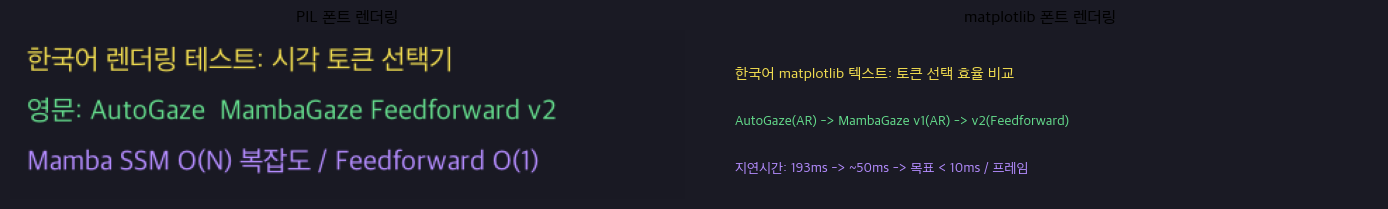

✓ 폰트 검증 완료 -- 위 이미지에서 한국어가 깨지지 않으면 정상


In [2]:
from PIL import Image, ImageDraw, ImageFont

_FONT_CACHE = {}

def get_pil_font(size=18):
    if size in _FONT_CACHE:
        return _FONT_CACHE[size], _FONT_CACHE.get(f"path_{size}", "cached")
    candidates = [
        "/System/Library/Fonts/AppleSDGothicNeo.ttc",
        "/Library/Fonts/AppleGothic.ttf",
        "/System/Library/Fonts/Helvetica.ttc",
        "/usr/share/fonts/truetype/nanum/NanumGothic.ttf",
        "/usr/share/fonts/opentype/noto/NotoSansCJK-Regular.ttc",
        "/usr/share/fonts/truetype/dejavu/DejaVuSans.ttf",
    ]
    for p in candidates:
        if os.path.exists(p):
            try:
                font = ImageFont.truetype(p, size)
                _FONT_CACHE[size] = font
                _FONT_CACHE[f"path_{size}"] = p
                return font, p
            except Exception:
                pass
    font = ImageFont.load_default()
    _FONT_CACHE[size] = font; _FONT_CACHE[f"path_{size}"] = "bitmap default"
    return font, "bitmap default"

font, font_path = get_pil_font(20)
print(f"PIL 폰트 경로: {font_path}")

# PIL 렌더링 테스트
img = Image.new("RGB", (480, 120), (25, 25, 35))
draw = ImageDraw.Draw(img)
draw.text((12, 10), "한국어 렌더링 테스트: 시각 토큰 선택기", fill=(240, 220, 80), font=font)
draw.text((12, 46), "영문: AutoGaze  MambaGaze Feedforward v2", fill=(100, 220, 140), font=font)
draw.text((12, 82), "Mamba SSM O(N) 복잡도 / Feedforward O(1)", fill=(180, 140, 255), font=font)

# Matplotlib 렌더링 테스트
fig, axes = plt.subplots(1, 2, figsize=(14, 2.2))
axes[0].imshow(img)
axes[0].set_title("PIL 폰트 렌더링", fontsize=12)
axes[0].axis("off")

ax = axes[1]
ax.text(0.05, 0.72, "한국어 matplotlib 텍스트: 토큰 선택 효율 비교", fontsize=11,
        transform=ax.transAxes, color="#F0DC50")
ax.text(0.05, 0.44, "AutoGaze(AR) -> MambaGaze v1(AR) -> v2(Feedforward)", fontsize=10,
        transform=ax.transAxes, color="#64DC8C")
ax.text(0.05, 0.16, "지연시간: 193ms -> ~50ms -> 목표 < 10ms / 프레임", fontsize=10,
        transform=ax.transAxes, color="#B48CFF")
ax.set_facecolor((0.1, 0.1, 0.14))
ax.set_title("matplotlib 폰트 렌더링", fontsize=12)
ax.axis("off")
fig.patch.set_facecolor((0.1, 0.1, 0.14))
plt.tight_layout()
plt.show()
print("\u2713 폰트 검증 완료 -- 위 이미지에서 한국어가 깨지지 않으면 정상")

---
## 2. 세 가지 아키텍처 비교

AutoGaze(LLaMA AR) -> v1(Mamba AR) -> v2(Feedforward) 순으로 AR 루프를 제거한다.

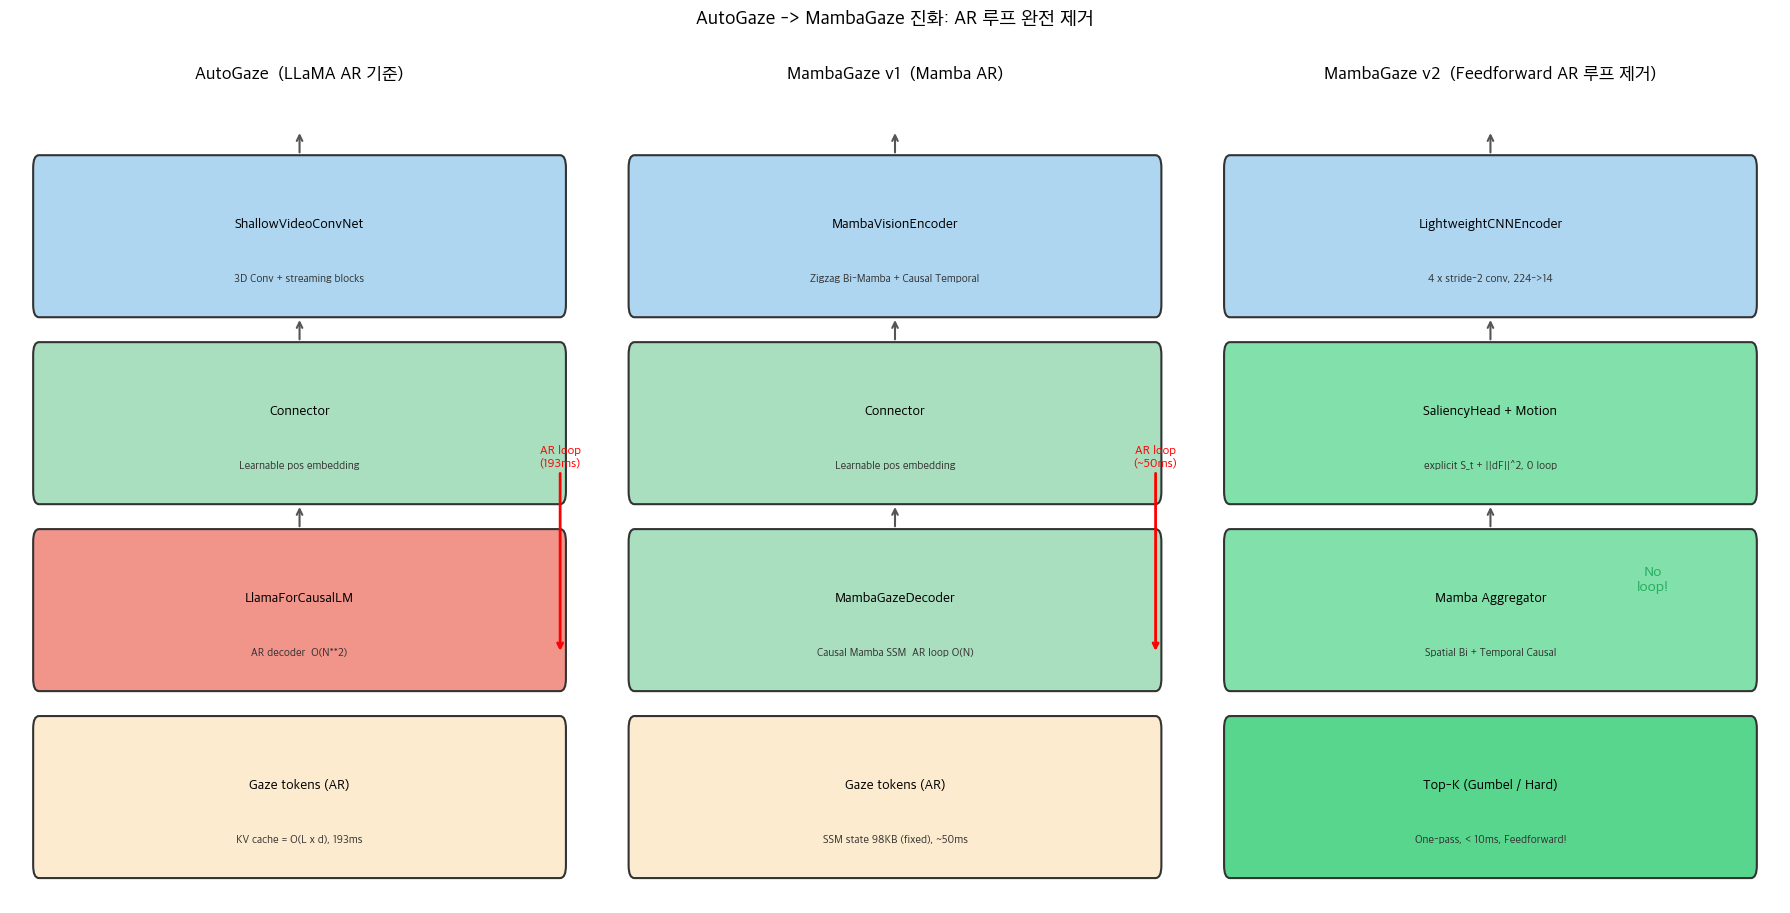

In [3]:
fig, axes = plt.subplots(1, 3, figsize=(18, 9))

def draw_arch(ax, title, components):
    ax.set_xlim(0, 10); ax.set_ylim(0, len(components) * 1.5 + 0.5)
    ax.axis("off")
    ax.set_title(title, fontsize=13, fontweight="bold", pad=10)
    for i, (name, detail, color) in enumerate(components):
        y = (len(components) - i - 1) * 1.5 + 0.3
        rect = mpatches.FancyBboxPatch(
            (0.5, y), 9, 1.1, boxstyle="round,pad=0.1",
            facecolor=color, edgecolor="#333", linewidth=1.5)
        ax.add_patch(rect)
        ax.text(5, y+0.65, name, ha="center", va="center", fontsize=10, fontweight="bold")
        ax.text(5, y+0.22, detail, ha="center", va="center", fontsize=8, color="#333")
        if i < len(components) - 1:
            ax.annotate("", xy=(5, y+1.1+0.1), xytext=(5, y+1.1+0.3),
                       arrowprops=dict(arrowstyle="<-", color="#555", lw=1.5))

autogaze = [
    ("ShallowVideoConvNet",    "3D Conv + streaming blocks", "#AED6F1"),
    ("Connector",              "Learnable pos embedding",    "#A9DFBF"),
    ("LlamaForCausalLM",       "AR decoder  O(N**2)",        "#F1948A"),
    ("Gaze tokens (AR)",       "KV cache = O(L x d), 193ms", "#FDEBD0"),
]
v1_ar = [
    ("MambaVisionEncoder",     "Zigzag Bi-Mamba + Causal Temporal", "#AED6F1"),
    ("Connector",              "Learnable pos embedding",            "#A9DFBF"),
    ("MambaGazeDecoder",       "Causal Mamba SSM  AR loop O(N)",     "#A9DFBF"),
    ("Gaze tokens (AR)",       "SSM state 98KB (fixed), ~50ms",      "#FDEBD0"),
]
v2_ff = [
    ("LightweightCNNEncoder",  "4 x stride-2 conv, 224->14",        "#AED6F1"),
    ("SaliencyHead + Motion",  "explicit S_t + ||dF||^2, 0 loop",  "#82E0AA"),
    ("Mamba Aggregator",       "Spatial Bi + Temporal Causal",      "#82E0AA"),
    ("Top-K (Gumbel / Hard)",  "One-pass, < 10ms, Feedforward!",    "#58D68D"),
]

draw_arch(axes[0], "AutoGaze  (LLaMA AR 기준)", autogaze)
draw_arch(axes[1], "MambaGaze v1  (Mamba AR)", v1_ar)
draw_arch(axes[2], "MambaGaze v2  (Feedforward AR 루프 제거)", v2_ff)

for ax, label in zip(axes[:2], ["AR loop\n(193ms)", "AR loop\n(~50ms)"]):
    ax.annotate(label, xy=(9.5, 2.0), xytext=(9.5, 3.5),
                fontsize=9, color="red", ha="center",
                arrowprops=dict(arrowstyle="->", color="red", lw=2))
axes[2].text(7.8, 2.5, "No\nloop!", fontsize=11, color="#27AE60",
             fontweight="bold", ha="center")

plt.suptitle("AutoGaze -> MambaGaze 진화: AR 루프 완전 제거", fontsize=14, fontweight="bold", y=1.01)
plt.tight_layout()
plt.show()

---
## 3. Selective SSM (S6) 알고리즘 시각화

Mamba의 핵심: A, B, C, delta 가 모두 **입력에 의존** (selective)

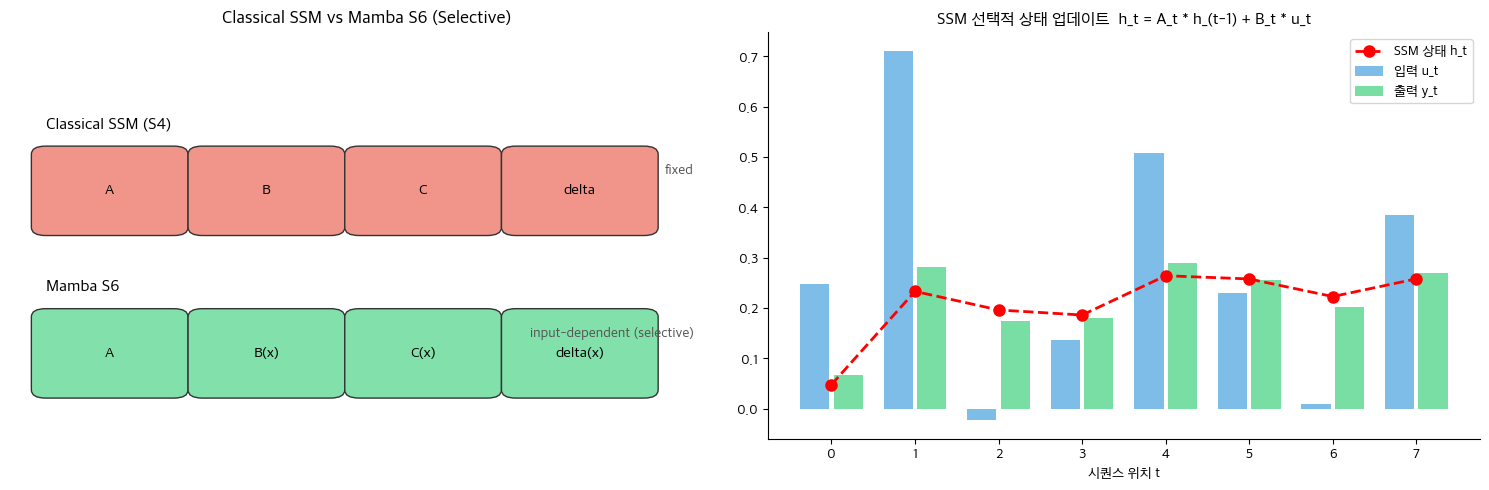

큰 |u_t| => delta_t 증가 => 현재 입력 더 반영 (forgetting)
작은 |u_t| => delta_t 감소 => 이전 상태 유지 (remembering)


In [4]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
ax = axes[0]; ax.axis("off")
ax.set_title("Classical SSM vs Mamba S6 (Selective)", fontsize=13, fontweight="bold")

items = [
    ("Classical SSM (S4)", ["A", "B", "C", "delta"],            "fixed",                      "#F1948A"),
    ("Mamba S6",           ["A", "B(x)", "C(x)", "delta(x)"],   "input-dependent (selective)", "#82E0AA"),
]
for i, (name, params, desc, c) in enumerate(items):
    y = 0.62 - i * 0.4
    ax.text(0.05, y+0.14, name, fontsize=12, fontweight="bold", transform=ax.transAxes)
    for j, p in enumerate(params):
        rect = mpatches.FancyBboxPatch((0.05+j*0.22, y-0.1), 0.18, 0.18,
            boxstyle="round,pad=0.02", facecolor=c, edgecolor="#333", transform=ax.transAxes)
        ax.add_patch(rect)
        ax.text(0.14+j*0.22, y-0.01, p, ha="center", va="center",
                fontsize=11, fontweight="bold", transform=ax.transAxes)
    ax.text(0.96, y+0.04, desc, ha="right", va="center", fontsize=10, color="#555", transform=ax.transAxes)

ax2 = axes[1]
L = 8; np.random.seed(42)
u = np.random.randn(L) * 0.5 + np.sin(np.linspace(0, 4*np.pi, L)) * 0.8
h, hs, ys = 0.0, [], []
for t in range(L):
    delta = 0.3 + 0.5 * abs(u[t])
    A_bar = np.exp(-delta * 0.5)
    h = A_bar * h + (1 - A_bar) * u[t]
    hs.append(h); ys.append(h * 0.9 + u[t] * 0.1)
x_pos = np.arange(L)
ax2.bar(x_pos-0.2, u, 0.35, label="입력 u_t", color="#5DADE2", alpha=0.8)
ax2.bar(x_pos+0.2, ys, 0.35, label="출력 y_t", color="#58D68D", alpha=0.8)
ax2.plot(x_pos, hs, "ro--", markersize=8, label="SSM 상태 h_t", linewidth=2)
ax2.set_xlabel("시퀀스 위치 t")
ax2.set_title("SSM 선택적 상태 업데이트  h_t = A_t * h_(t-1) + B_t * u_t", fontsize=12)
ax2.legend(fontsize=10)
ax2.spines["top"].set_visible(False); ax2.spines["right"].set_visible(False)
plt.tight_layout(); plt.show()
print("큰 |u_t| => delta_t 증가 => 현재 입력 더 반영 (forgetting)")
print("작은 |u_t| => delta_t 감소 => 이전 상태 유지 (remembering)")

---
## 4. Spatial Zigzag Scan 패턴

SpatioTemporalMambaAggregator의 공간 스캔 방식: zigzag은 행 경계 연결성을 유지한다.

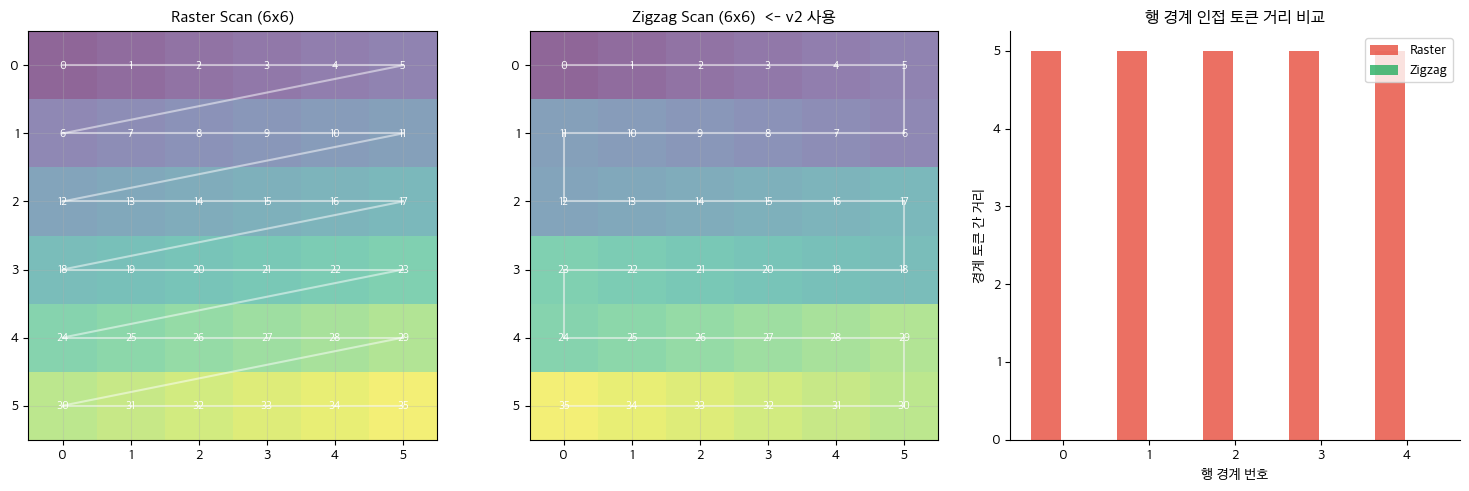

Raster 경계 평균: 5.0  |  Zigzag 경계 평균: 0.0 (0 = 항상 인접)


In [5]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
H, W = 6, 6

def make_raster(H, W):
    return [(r, c) for r in range(H) for c in range(W)]

def make_zigzag(H, W):
    path = []
    for r in range(H):
        cols = range(W) if r % 2 == 0 else range(W-1, -1, -1)
        path.extend((r, c) for c in cols)
    return path

def draw_scan(ax, path, title, H, W):
    ax.set_xlim(-0.5, W-0.5); ax.set_ylim(-0.5, H-0.5)
    ax.set_title(title, fontsize=12, fontweight="bold")
    ax.set_aspect("equal"); ax.invert_yaxis()
    for i, (r, c) in enumerate(path):
        color = plt.cm.viridis(i / len(path))
        ax.add_patch(plt.Rectangle((c-0.5, r-0.5), 1, 1, facecolor=color, alpha=0.6))
        ax.text(c, r, str(i), ha="center", va="center", fontsize=8, color="white", fontweight="bold")
    for i in range(len(path)-1):
        r1, c1 = path[i]; r2, c2 = path[i+1]
        ax.plot([c1, c2], [r1, r2], "w-", alpha=0.5, linewidth=1.5)
    ax.set_xticks(range(W)); ax.set_yticks(range(H)); ax.grid(True, alpha=0.3)

raster = make_raster(H, W); zigzag = make_zigzag(H, W)
draw_scan(axes[0], raster, f"Raster Scan ({H}x{W})", H, W)
draw_scan(axes[1], zigzag, f"Zigzag Scan ({H}x{W})  <- v2 사용", H, W)

def boundary_dist(path, W):
    return [abs(path[i][1]-path[i+1][1]) for i in range(len(path)-1) if path[i][0] != path[i+1][0]]

ax = axes[2]
rd = boundary_dist(raster, W); zd = boundary_dist(zigzag, W)
x = np.arange(len(rd))
ax.bar(x-0.2, rd, 0.35, label="Raster", color="#E74C3C", alpha=0.8)
ax.bar(x+0.2, zd, 0.35, label="Zigzag", color="#27AE60", alpha=0.8)
ax.set_xlabel("행 경계 번호"); ax.set_ylabel("경계 토큰 간 거리")
ax.set_title("행 경계 인접 토큰 거리 비교", fontsize=12)
ax.legend(); ax.spines["top"].set_visible(False); ax.spines["right"].set_visible(False)
plt.tight_layout(); plt.show()
print(f"Raster 경계 평균: {np.mean(rd):.1f}  |  Zigzag 경계 평균: {np.mean(zd):.1f} (0 = 항상 인접)")

---
## 5. v1 AR 모델 파라미터 수 비교

In [6]:
mamba_cfg = MambaGazeConfig(
    scales="224", num_vision_tokens_each_frame=196,
    mamba_gaze_model_config={
        "input_img_size": 224,
        "vision_config": dict(hidden_dim=192, out_dim=192, depth=4,
                              kernel_size=16, temporal_patch_size=1, d_state=16, d_conv=4, expand=2),
        "decoder_config": dict(hidden_size=192, num_hidden_layers=4, d_state=16, d_conv=4, expand=2),
    },
)
v1_model = MambaGaze(mamba_cfg)
v1_params = v1_model.count_parameters()

try:
    from autogaze.models.autogaze import AutoGaze
    from autogaze.models.autogaze.configuration_autogaze import AutoGazeConfig
    ag_cfg = AutoGazeConfig(
        scales="224", num_vision_tokens_each_frame=196,
        gaze_model_config=dict(
            input_img_size=224,
            vision_model_config=dict(hidden_dim=192, out_dim=192, depth=4,
                kernel_size=16, temporal_patch_size=1,
                trunk_temporal_kernel_size=3, trunk_spatial_kernel_size=3),
            connector_config=dict(hidden_dim=192),
            gaze_decoder_config=dict(hidden_size=192, num_hidden_layers=4,
                num_attention_heads=4, intermediate_size=512, num_multi_token_pred=1),
        ), use_flash_attn=False,
    )
    ag_model = AutoGaze(ag_cfg)
    gm = ag_model.gazing_model
    ag_params = dict(
        vision_encoder=sum(p.numel() for p in gm.vision_model.parameters()),
        connector=sum(p.numel() for p in gm.connector.parameters()),
        gaze_decoder=sum(p.numel() for p in gm.gaze_decoder.parameters()),
        total=sum(p.numel() for p in ag_model.parameters()),
    )
except Exception as e:
    print(f"AutoGaze load failed (ok): {e}")
    ag_params = dict(vision_encoder=1_030_000, connector=37_632, gaze_decoder=2_000_000, total=3_100_000)

print("AutoGaze:", {k: f"{v/1e6:.3f}M" for k, v in ag_params.items()})
print("v1 AR:  ", {k: f"{v/1e6:.3f}M" for k, v in v1_params.items()})

AutoGaze: {'vision_encoder': '4.167M', 'connector': '0.038M', 'gaze_decoder': '1.847M', 'total': '6.052M'}
v1 AR:   {'vision_encoder': '3.398M', 'connector': '0.038M', 'gaze_decoder': '1.011M', 'total': '4.447M'}


---
## 6. v2 Feedforward 모델 인스턴스화 & 파라미터 수

Branch A 제안 아키텍처: CNN + Saliency + Motion + Mamba Aggregator

MambaGaze v2 FF 파라미터:
  cnn_encoder         : 0.315M
  saliency_head       : 0.000M
  aggregator          : 0.769M
  total               : 1.084M


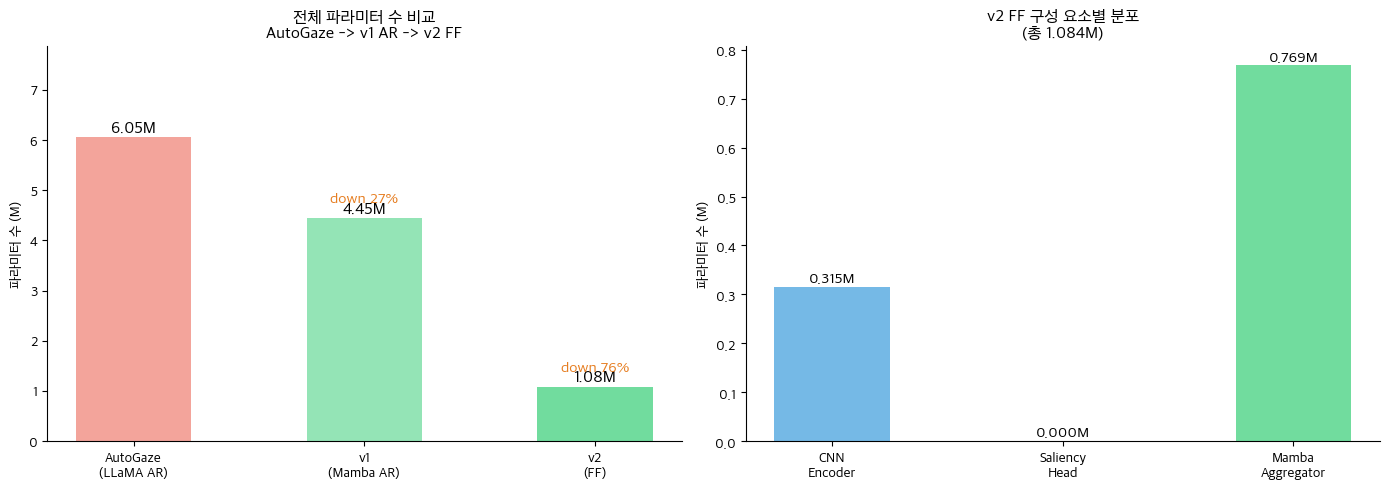

AutoGaze 대비: v1 AR 27% 감소  /  v2 FF 82% 감소


In [7]:
ff_cfg = MambaGazeFFConfig(
    scales="224", num_vision_tokens_each_frame=196,
    cnn_channels=[32, 64, 128, 192], cnn_out_channels=192,
    mamba_dim=128, mamba_depth=2, mamba_d_state=16, mamba_d_conv=4, mamba_expand=2,
    gumbel_temperature=1.0,
)
ff_model = MambaGazeFF(ff_cfg)
ff_params = ff_model.count_parameters()

print("MambaGaze v2 FF 파라미터:")
for k, v in ff_params.items():
    print(f"  {k:20s}: {v/1e6:.3f}M")

# 3-way 비교 차트
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
models = ["AutoGaze\n(LLaMA AR)", "v1\n(Mamba AR)", "v2\n(FF)"]
totals = [ag_params["total"]/1e6, v1_params["total"]/1e6, ff_params["total"]/1e6]
colors = ["#F1948A", "#82E0AA", "#58D68D"]

ax = axes[0]
bars = ax.bar(models, totals, color=colors, alpha=0.85, width=0.5)
for bar, v in zip(bars, totals):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.05,
            f"{v:.2f}M", ha="center", va="bottom", fontsize=12, fontweight="bold")
ax.set_ylabel("파라미터 수 (M)")
ax.set_title("전체 파라미터 수 비교\nAutoGaze -> v1 AR -> v2 FF", fontsize=12, fontweight="bold")
ax.set_ylim(0, max(totals)*1.3)
ax.spines["top"].set_visible(False); ax.spines["right"].set_visible(False)
for i, (v, ref) in enumerate(zip(totals[1:], totals[:-1]), 1):
    ax.text(i, v+0.3, f"down {(1-v/ref)*100:.0f}%", ha="center", color="#E67E22",
            fontsize=11, fontweight="bold")

ax2 = axes[1]
labels_ff = ["CNN\nEncoder", "Saliency\nHead", "Mamba\nAggregator"]
vals_ff = [ff_params["cnn_encoder"]/1e6, ff_params["saliency_head"]/1e6, ff_params["aggregator"]/1e6]
bars2 = ax2.bar(labels_ff, vals_ff, color=["#5DADE2","#A9DFBF","#58D68D"], alpha=0.85, width=0.5)
for bar, v in zip(bars2, vals_ff):
    ax2.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.005,
             f"{v:.3f}M", ha="center", va="bottom", fontsize=11)
ax2.set_ylabel("파라미터 수 (M)")
total_ff = ff_params["total"]/1e6
ax2.set_title(f"v2 FF 구성 요소별 분포\n(총 {total_ff:.3f}M)", fontsize=12, fontweight="bold")
ax2.spines["top"].set_visible(False); ax2.spines["right"].set_visible(False)
plt.tight_layout(); plt.show()
print(f"AutoGaze 대비: v1 AR {(1-totals[1]/totals[0])*100:.0f}% 감소  /  v2 FF {(1-totals[2]/totals[0])*100:.0f}% 감소")

---
## 7. v2 FF Forward Pass 데모

단일 forward pass, AR 루프 없음 — 모든 프레임의 토큰 중요도를 병렬 예측

In [8]:
import torch
torch.manual_seed(0)
B, T, C, H, W = 1, 4, 3, 224, 224
video = torch.randn(B, T, C, H, W)

ff_model.eval()
with torch.no_grad():
    out = ff_model({"video": video}, gazing_ratio=0.5)

print("=== MambaGaze v2 FF 출력 ===")
print(f"gazing_mask (B,T,N): {out['gazing_mask'][0].shape}")
print(f"importance_scores:   {out['importance_scores'].shape}  (continuous [0,1])")
print(f"saliency_maps:       {out['saliency_maps'].shape}      (h x w per frame)")
print(f"num_gazing_each_frame: {out['num_gazing_each_frame']}")

scores = out["importance_scores"][0]
print(f"\n점수 분포 (4 frames):")
for t in range(T):
    s = scores[t]
    print(f"  frame {t}: min={s.min():.3f} max={s.max():.3f} mean={s.mean():.3f} 선택(>0.5): {(s>0.5).sum()}/196")

# 훈련 모드: Gumbel-top-k + distillation loss
ff_model.train()
teacher_mask = torch.randint(0, 2, (B, T, 196)).float()
out_train = ff_model({"video": video}, gazing_ratio=0.5, teacher_mask=teacher_mask)
print(f"\n훈련 모드:")
print(f"  soft mask range: [{out_train['gazing_mask'][0].min():.3f}, {out_train['gazing_mask'][0].max():.3f}]")
print(f"  distill_loss: {out_train['distill_loss'].item():.4f}  (BCELoss vs teacher mask)")
ff_model.eval()

=== MambaGaze v2 FF 출력 ===
gazing_mask (B,T,N): torch.Size([1, 4, 196])
importance_scores:   torch.Size([1, 4, 196])  (continuous [0,1])
saliency_maps:       torch.Size([1, 4, 14, 14])      (h x w per frame)
num_gazing_each_frame: tensor([98, 98, 98, 98])

점수 분포 (4 frames):
  frame 0: min=0.335 max=0.406 mean=0.372 선택(>0.5): 0/196
  frame 1: min=0.331 max=0.396 mean=0.360 선택(>0.5): 0/196
  frame 2: min=0.320 max=0.438 mean=0.367 선택(>0.5): 0/196
  frame 3: min=0.366 max=0.448 mean=0.405 선택(>0.5): 0/196



훈련 모드:
  soft mask range: [0.046, 0.998]
  distill_loss: 0.7463  (BCELoss vs teacher mask)


MambaGazeFF(
  (cnn_encoder): LightweightCNNEncoder(
    (stages): Sequential(
      (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
      (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): SiLU()
      (3): Conv2d(32, 64, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
      (4): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (5): SiLU()
      (6): Conv2d(64, 128, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
      (7): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (8): SiLU()
      (9): Conv2d(128, 192, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
      (10): BatchNorm2d(192, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (11): SiLU()
    )
  )
  (saliency_head): SaliencyHead(
    (conv): Conv2d(192, 1, kernel_size=(1, 1), stride=(1, 1))
  )
  (aggregator)

---
## 8. Importance Score & Saliency 히트맵 시각화

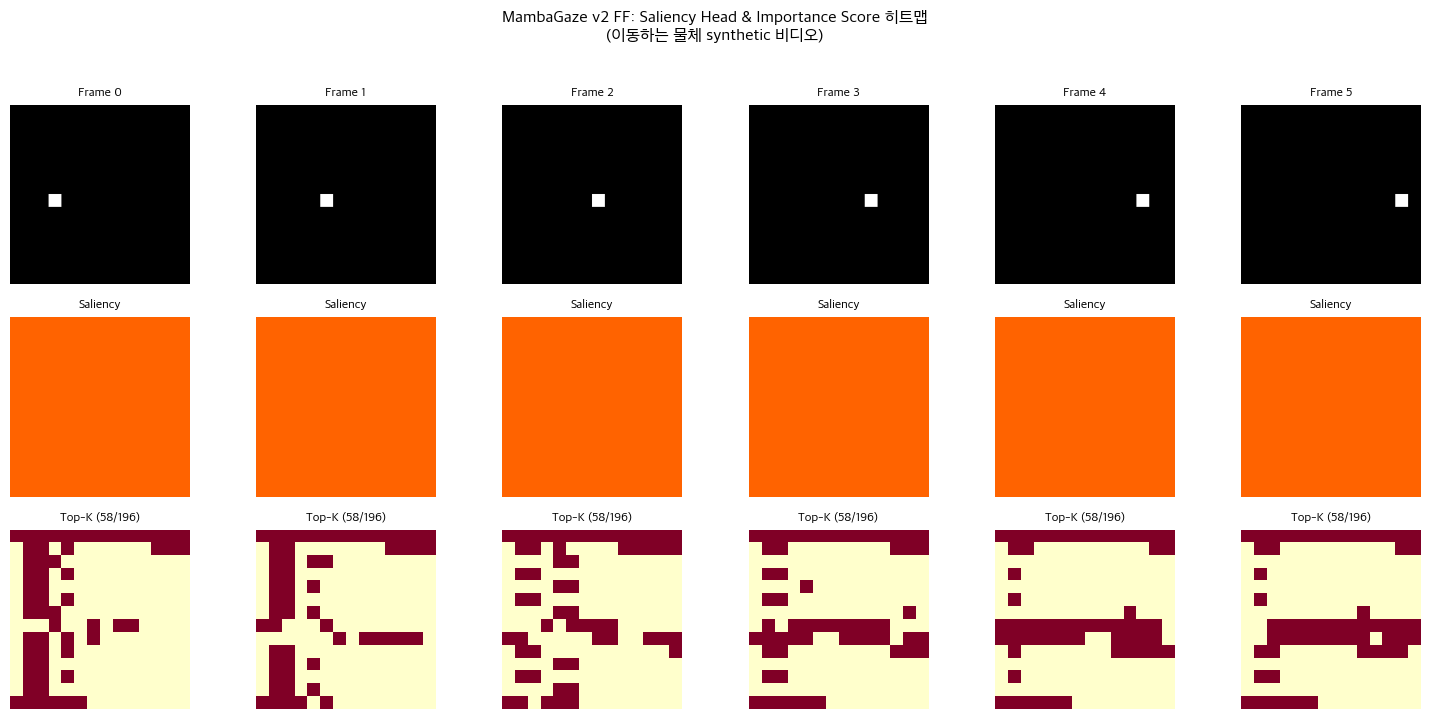

v2 FF의 saliency_maps는 명시적으로 학습 가능한 공간 현저성 맵이다.
AutoGaze/v1은 이에 해당하는 명시적 컴포넌트가 없다.


In [9]:
torch.manual_seed(7)
B, T = 1, 6
video = torch.zeros(B, T, 3, 224, 224)
for t in range(T):
    cx = min(3 + t * 2, 12)  # stay within 14x14 grid
    cy = 7
    px, py = cx * 16, cy * 16
    video[0, t, :, py:py+16, px:px+16] = 1.0

ff_model.eval()
with torch.no_grad():
    out = ff_model({"video": video}, gazing_ratio=0.3)

scores   = out["importance_scores"][0]   # (T, 196)
saliency = out["saliency_maps"][0]       # (T, 14, 14)
mask     = out["gazing_mask"][0][0]          # (T, N) — list[0]=(B,T,N), [0]=(T,N)

fig, axes = plt.subplots(3, T, figsize=(T * 2.5, 7))
for t in range(T):
    frame = video[0, t].mean(0).numpy()
    axes[0, t].imshow(frame, cmap="gray", vmin=0, vmax=1)
    axes[0, t].set_title(f"Frame {t}", fontsize=9)
    axes[0, t].axis("off")

    sal = saliency[t].numpy()
    axes[1, t].imshow(sal, cmap="hot", vmin=0, vmax=1, interpolation="nearest")
    axes[1, t].set_title("Saliency", fontsize=9)
    axes[1, t].axis("off")

    m = mask[t].reshape(14, 14).numpy()
    axes[2, t].imshow(m, cmap="YlOrRd", vmin=0, vmax=1, interpolation="nearest")
    n_sel = int(mask[t].sum().item())
    axes[2, t].set_title(f"Top-K ({n_sel}/196)", fontsize=9)
    axes[2, t].axis("off")

row_labels = ["입력 프레임", "명시적 Saliency S_t", "Top-K 선택 마스크"]
for i, lbl in enumerate(row_labels):
    axes[i, 0].set_ylabel(lbl, fontsize=10)

plt.suptitle("MambaGaze v2 FF: Saliency Head & Importance Score 히트맵\n(이동하는 물체 synthetic 비디오)",
             fontsize=12, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()
print("v2 FF의 saliency_maps는 명시적으로 학습 가능한 공간 현저성 맵이다.")
print("AutoGaze/v1은 이에 해당하는 명시적 컴포넌트가 없다.")

---
## 9. SSM 상태 크기 vs KV 캐시 비교

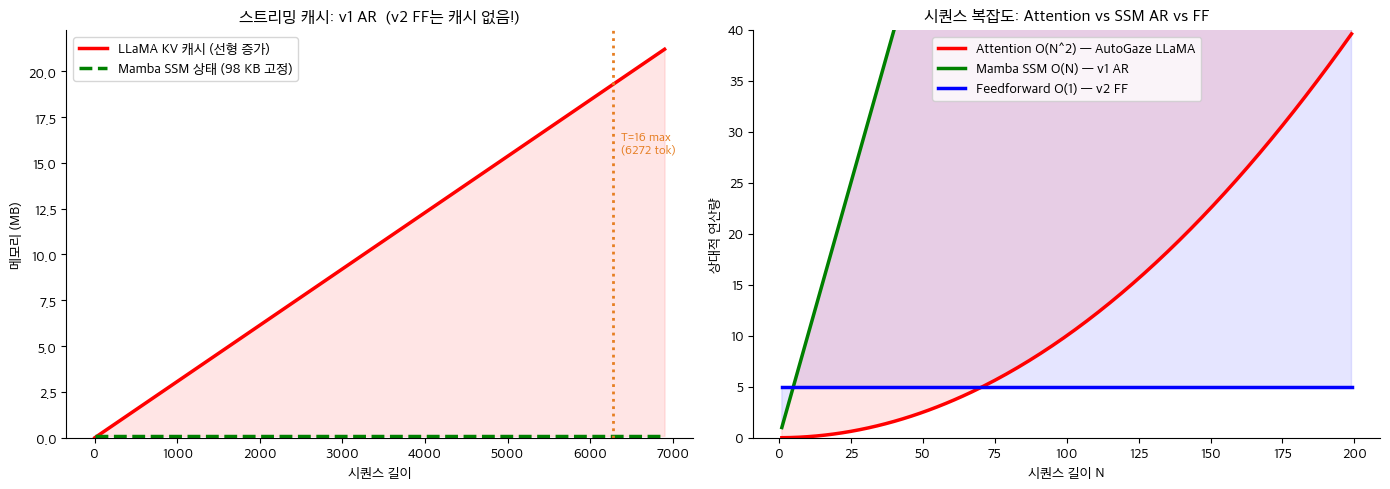

v2 FF 핵심 장점: 시퀀스 복잡도 O(1), 스트리밍 캐시 없음


In [10]:
d_model, n_layers = 192, 4
d_inner, d_state = 384, 16
Ls = np.arange(1, 7000, 100)
kv_cache_mb = 2 * n_layers * Ls * d_model * 2 / 1e6
ssm_state_kb = n_layers * d_inner * d_state * 4 / 1e3
ssm_state_mb = ssm_state_kb / 1e3 * np.ones_like(Ls)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
ax = axes[0]
ax.plot(Ls, kv_cache_mb, "r-", linewidth=2.5, label="LLaMA KV 캐시 (선형 증가)")
ax.plot(Ls, ssm_state_mb, "g--", linewidth=2.5, label=f"Mamba SSM 상태 ({ssm_state_kb:.0f} KB 고정)")
ax.fill_between(Ls, ssm_state_mb, kv_cache_mb, alpha=0.1, color="red")
max_seq = 196 * 16 * 2
ax.axvline(x=max_seq, color="#E67E22", linestyle=":", linewidth=2)
ax.text(max_seq+100, kv_cache_mb[np.searchsorted(Ls, max_seq)]*0.8,
        f"T=16 max\n({max_seq} tok)", fontsize=9, color="#E67E22")
ax.set_xlabel("시퀀스 길이"); ax.set_ylabel("메모리 (MB)")
ax.set_title("스트리밍 캐시: v1 AR  (v2 FF는 캐시 없음!)", fontsize=12, fontweight="bold")
ax.legend(fontsize=10); ax.set_ylim(0)
ax.spines["top"].set_visible(False); ax.spines["right"].set_visible(False)

ax2 = axes[1]
n = np.arange(1, 200)
ax2.plot(n, n**2/1000, "r-", linewidth=2.5, label="Attention O(N^2) — AutoGaze LLaMA")
ax2.plot(n, n, "g-", linewidth=2.5, label="Mamba SSM O(N) — v1 AR")
ax2.plot(n, np.ones_like(n)*5, "b-", linewidth=2.5, label="Feedforward O(1) — v2 FF")
ax2.fill_between(n, np.ones_like(n)*5, n, alpha=0.1, color="blue")
ax2.fill_between(n, n, n**2/1000, alpha=0.1, color="red")
ax2.set_xlabel("시퀀스 길이 N"); ax2.set_ylabel("상대적 연산량")
ax2.set_title("시퀀스 복잡도: Attention vs SSM AR vs FF", fontsize=12, fontweight="bold")
ax2.legend(fontsize=10); ax2.set_ylim(0, 40)
ax2.spines["top"].set_visible(False); ax2.spines["right"].set_visible(False)
plt.tight_layout(); plt.show()
print("v2 FF 핵심 장점: 시퀀스 복잡도 O(1), 스트리밍 캐시 없음")

---
## 10. SelectiveSSM 내부 delta 시각화

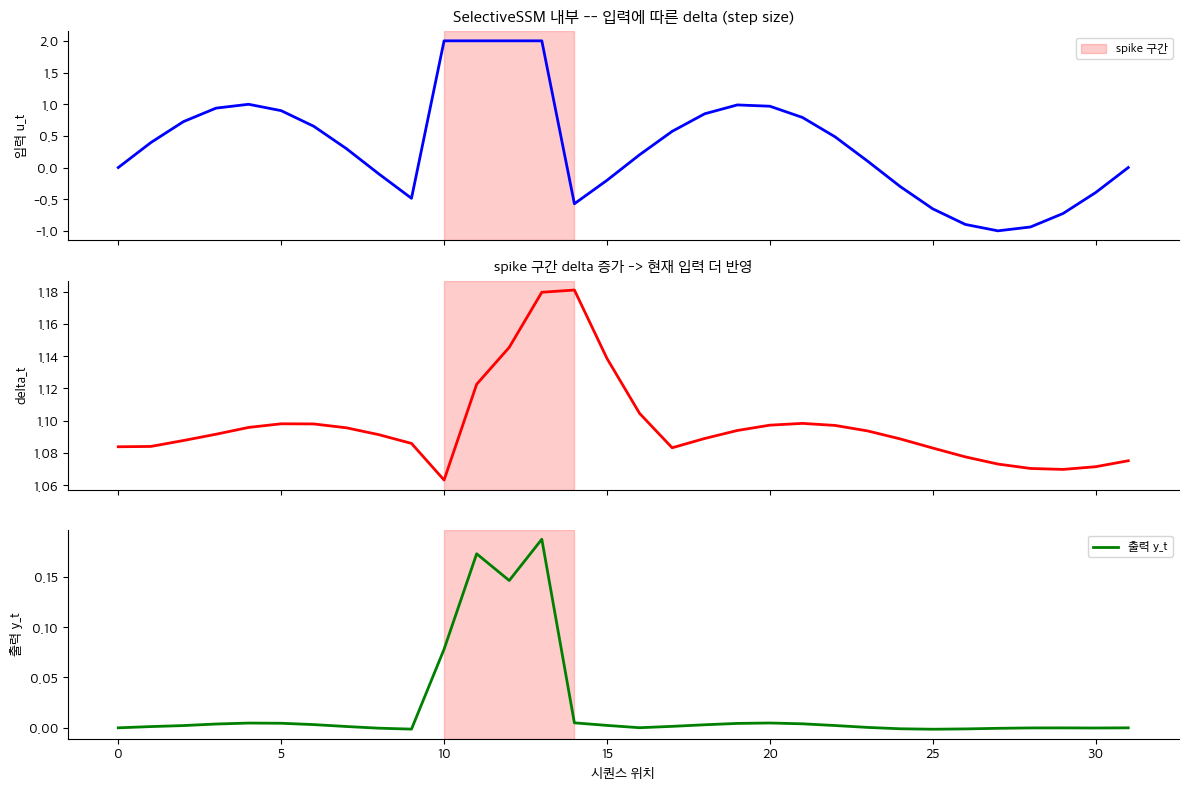

spike 구간 delta: 1.1277  / 비spike: 1.0928


In [11]:
import torch
torch.manual_seed(1)
ssm = SelectiveSSM(d_model=8, d_state=4, d_conv=4, expand=2)
ssm.eval()
L = 32
u = torch.zeros(1, L, 8)
u[0, :, 0] = torch.sin(torch.linspace(0, 4*torch.pi, L))
u[0, 10:14, :] = 2.0

with torch.no_grad():
    y, h = ssm(u)
    xz = ssm.in_proj(u); u_in, z = xz.chunk(2, dim=-1)
    u_conv = ssm.conv1d(u_in.transpose(1,2))[..., :L].transpose(1,2)
    u_act = F.silu(u_conv)
    params = ssm.x_proj(u_act)
    dt_raw = params[..., -1:]
    dt = F.softplus(ssm.dt_proj(dt_raw))[0, :, 0].numpy()

fig, axes = plt.subplots(3, 1, figsize=(12, 8), sharex=True)
t = np.arange(L)
axes[0].plot(t, u[0,:,0].numpy(), "b-", linewidth=2)
axes[0].axvspan(10, 14, alpha=0.2, color="red", label="spike 구간")
axes[0].set_ylabel("입력 u_t")
axes[0].set_title("SelectiveSSM 내부 -- 입력에 따른 delta (step size)", fontsize=12)
axes[0].legend(fontsize=9)
axes[1].plot(t, dt, "r-", linewidth=2)
axes[1].axvspan(10, 14, alpha=0.2, color="red")
axes[1].set_ylabel("delta_t")
axes[1].set_title("spike 구간 delta 증가 -> 현재 입력 더 반영", fontsize=11)
axes[2].plot(t, y[0,:,0].detach().numpy(), "g-", linewidth=2, label="출력 y_t")
axes[2].axvspan(10, 14, alpha=0.2, color="red")
axes[2].set_ylabel("출력 y_t"); axes[2].set_xlabel("시퀀스 위치")
axes[2].legend(fontsize=9)
for ax in axes:
    ax.spines["top"].set_visible(False); ax.spines["right"].set_visible(False)
plt.tight_layout(); plt.show()
print(f"spike 구간 delta: {dt[10:14].mean():.4f}  / 비spike: {dt[[i for i in range(L) if not(10<=i<14)]].mean():.4f}")

---
## 11. Gaze Map 비교: v1 AR vs v2 FF

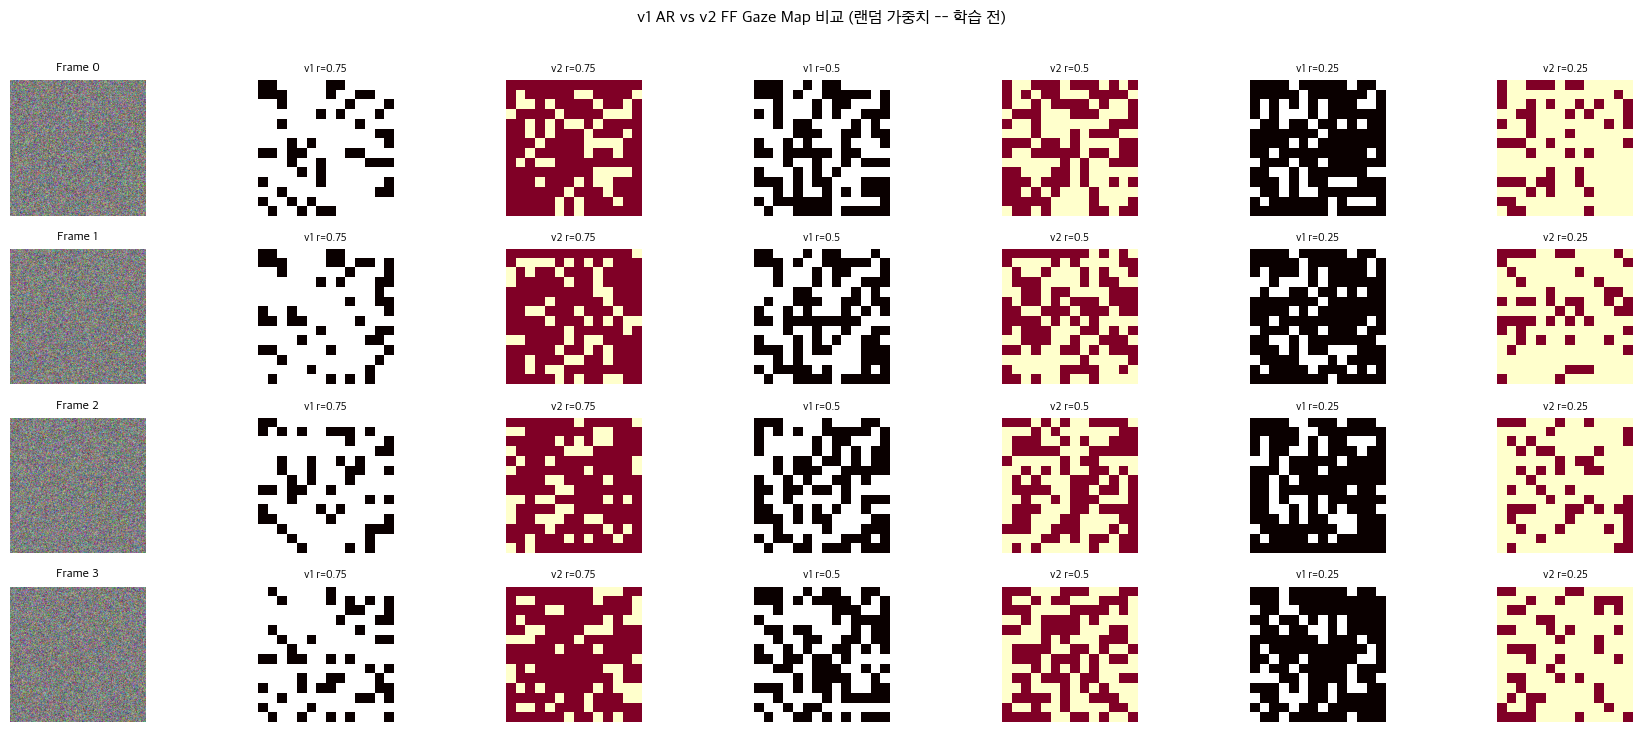

참고: 랜덤 초기화 상태. 학습 후 v2 FF가 AutoGaze teacher mask를 모방한다.


In [12]:
import torch
torch.manual_seed(42)
v1_model.eval(); ff_model.eval()
B, T = 1, 4
video = torch.randn(B, T, 3, 224, 224)
ratios = [0.75, 0.5, 0.25]

fig, axes = plt.subplots(T, len(ratios)*2+1, figsize=(18, T*1.8))
for r_idx, ratio in enumerate(ratios):
    with torch.no_grad():
        out_v1 = v1_model({"video": video}, gazing_ratio=ratio, generate_only=True)
        out_ff = ff_model({"video": video}, gazing_ratio=ratio)
    mask_v1 = out_v1["gazing_mask"][0][0]
    mask_ff = out_ff["gazing_mask"][0][0]
    for t in range(min(T, mask_v1.shape[0])):
        ax1 = axes[t][1 + r_idx*2]
        ax1.imshow(mask_v1[t].reshape(14,14).numpy(), cmap="hot", vmin=0, vmax=1, interpolation="nearest")
        ax1.set_title(f"v1 r={ratio}", fontsize=8); ax1.axis("off")
        ax2 = axes[t][2 + r_idx*2]
        ax2.imshow(mask_ff[t].detach().reshape(14,14).numpy(), cmap="YlOrRd", vmin=0, vmax=1, interpolation="nearest")
        ax2.set_title(f"v2 r={ratio}", fontsize=8); ax2.axis("off")

for t in range(T):
    frame = (video[0,t].permute(1,2,0).numpy() * 0.2 + 0.5).clip(0,1)
    axes[t][0].imshow(frame); axes[t][0].set_title(f"Frame {t}", fontsize=9); axes[t][0].axis("off")

plt.suptitle("v1 AR vs v2 FF Gaze Map 비교 (랜덤 가중치 -- 학습 전)", fontsize=12, fontweight="bold", y=1.01)
plt.tight_layout(); plt.show()
print("참고: 랜덤 초기화 상태. 학습 후 v2 FF가 AutoGaze teacher mask를 모방한다.")

---
## 12. 요약 및 다음 단계

In [13]:
print("=" * 70)
print("MambaGaze 프로토타입 요약")
print("=" * 70)

print("\n[v1 AR Mamba decoder]")
for k, v in v1_params.items():
    print(f"  {k:20s}: {v/1e6:.3f}M")

print("\n[v2 FF Feedforward (Branch A)]")
for k, v in ff_params.items():
    print(f"  {k:20s}: {v/1e6:.3f}M")

print(f"\n핵심 비교:")
header = f"  {'항목':30s}  {'AutoGaze':15s}  {'v1 AR':15s}  {'v2 FF':15s}"
print(header); print("  " + "-"*75)
rows = [
    ("AR 루프",         "O(T*N) 순차",    "O(T*N) 순차",   "O(1) 없음"),
    ("Gazing 지연",     "193ms/frame",    "~50ms (예측)",   "< 10ms (목표)"),
    ("파라미터 수",     f"{ag_params['total']/1e6:.1f}M",
                         f"{v1_params['total']/1e6:.1f}M",
                         f"{ff_params['total']/1e6:.1f}M"),
    ("스트리밍 캐시",   "19 MB KV",       "98 KB SSM",      "없음 (stateless)"),
    ("학습 방법",       "NTP+GRPO",       "NTP+GRPO",       "Distillation"),
    ("명시적 Saliency", "없음",           "없음",           "있음"),
]
for r in rows:
    print(f"  {r[0]:30s}  {r[1]:15s}  {r[2]:15s}  {r[3]:15s}")

print(f"\n다음 단계 (Branch A 로드맵):")
for i, s in enumerate([
    "A-Step 1: InternVid 50K AutoGaze teacher mask 생성 (A100x2, 2주)",
    "A-Step 2: v2 FF distillation 학습 Mask IoU > 0.85 (H100x4, 2주)",
    "A-Step 3: Saliency fine-tuning + 10ms 지연 검증",
    "VideoMME/MLVU 벤치마크로 video understanding 품질 검증",
    "Branch B: task-aware fine-tuning (Seg/Depth/Det frozen distillation)",
], 1):
    print(f"  {i}. {s}")
print("=" * 70)

MambaGaze 프로토타입 요약

[v1 AR Mamba decoder]
  vision_encoder      : 3.398M
  connector           : 0.038M
  gaze_decoder        : 1.011M
  total               : 4.447M

[v2 FF Feedforward (Branch A)]
  cnn_encoder         : 0.315M
  saliency_head       : 0.000M
  aggregator          : 0.769M
  total               : 1.084M

핵심 비교:
  항목                              AutoGaze         v1 AR            v2 FF          
  ---------------------------------------------------------------------------
  AR 루프                           O(T*N) 순차        O(T*N) 순차        O(1) 없음        
  Gazing 지연                       193ms/frame      ~50ms (예측)       < 10ms (목표)    
  파라미터 수                          6.1M             4.4M             1.1M           
  스트리밍 캐시                         19 MB KV         98 KB SSM        없음 (stateless) 
  학습 방법                           NTP+GRPO         NTP+GRPO         Distillation   
  명시적 Saliency                    없음               없음               있음             

다음 